<span style="font-size:20px">****NAIVE ENCODING****</span>
<br>This project encodes DNA strand pairs into numerical vector representations using a trained ProtVec-style model. Each pair is split into two sequences, individually embedded, and concatenated. Based on experimental melting temperatures (Temp Exp), the pairs are grouped into temperature buckets. Cosine similarity is then used to measure how closely related the embeddings are—both within and between these temperature-defined groups. The results are visualized in a heatmap to reveal patterns in sequence similarity across thermal ranges.

In [1]:
import biovec
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models import KeyedVectors
from scipy.spatial.distance import cosine
from itertools import combinations 

CSV_PATH = "Oliveira Table.txt"
MODEL_PATH = "kim_dna_protvec.model"
TEMP_COL = "Temp Exp"


In [2]:
# # Buckets
# df = pd.read_csv(CSV_PATH)
# BUCKET_SIZE = 2 # CHANGE BUCKET GRAN. HERE

# min_temp = df[TEMP_COL].min()
# max_temp = df[TEMP_COL].max()

# start_edge = BUCKET_SIZE * np.floor(min_temp / BUCKET_SIZE)
# end_edge = BUCKET_SIZE * np.ceil(max_temp / BUCKET_SIZE)
# bins = np.arange(start_edge, end_edge + BUCKET_SIZE, BUCKET_SIZE)
# labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins) - 1)]

# df["T_bucket"] = pd.cut(df[TEMP_COL], bins=bins, labels=labels, include_lowest=True)
# df["T_bucket"].value_counts().sort_index()
df = pd.read_csv(CSV_PATH)

NUM_BUCKETS = 20  # choose how many buckets you want

# Compute quantile cut points
quantiles = np.linspace(0, 1, NUM_BUCKETS + 1)
bins = df[TEMP_COL].quantile(quantiles).values

# Drop duplicates in case some quantiles collapse (e.g., flat regions)
bins = np.unique(bins)

labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins) - 1)]

df["T_bucket"] = pd.cut(df[TEMP_COL], bins=bins, labels=labels, include_lowest=True)

# Check distribution: each bucket should have ~equal counts
print(df["T_bucket"].value_counts().sort_index())

T_bucket
41.3-46.3    216
46.3-47.3    215
47.3-47.9    185
47.9-48.5    209
48.5-49.0    220
49.0-49.5    185
49.5-50.1    270
50.1-50.5    171
50.5-51.0    212
51.0-51.5    204
51.5-52.0    169
52.0-52.6    209
52.6-53.3    226
53.3-54.0    215
54.0-54.6    169
54.6-55.4    214
55.4-56.5    201
56.5-57.8    202
57.8-60.0    203
60.0-69.3    201
Name: count, dtype: int64


In [3]:
# Load data
def split_centre(s):
    s = str(s)
    left, right = s.split("/", 1)
    return left.strip(), right.strip()

seqs = df["Centre"].apply(split_centre)
df["Seq1"] = seqs.apply(lambda x: x[0])
df["Seq2"] = seqs.apply(lambda x: x[1])

df.head()

,Unnamed: 0,i,Centre,Temp Exp,Temp Pred,Melt Index,Mismatches,T_bucket,Seq1,Seq2
0,0,1,GCG/CGC,69.3,71.47,3.8891,0,60.0-69.3,GCG,CGC
1,1,2,CGC/GCG,69.1,69.73,3.8559,0,60.0-69.3,CGC,GCG
2,2,3,GGC/CCG,68.9,69.73,3.8559,0,60.0-69.3,GGC,CCG
3,3,4,GCC/CGG,68.7,69.73,3.8559,0,60.0-69.3,GCC,CGG
4,4,5,CGG/GCC,68.2,70.50,3.8707,0,60.0-69.3,CGG,GCC


In [4]:
# Encode
kv = KeyedVectors.load("kim_dna_protvec.model", mmap="r")

def encode_seq(seq, k=3):
    seq = seq.upper().strip()
    kmers = [seq[i:i+k] for i in range(len(seq) - k + 1)]
    vecs = [kv.wv[kmer] for kmer in kmers if kmer in kv.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(kv.vector_size)

def encode_pair_concat(s1, s2):
    return np.concatenate([encode_seq(s1), encode_seq(s2)])

df["concat_embedding"] = [encode_pair_concat(s1, s2) for s1, s2 in zip(df["Seq1"], df["Seq2"])]

In [5]:
# Size sanity check  
print("Seq1 shape:", encode_seq(df["Seq1"].iloc[0]).shape)
print("Seq2 shape:", encode_seq(df["Seq2"].iloc[0]).shape)
print(df["concat_embedding"].iloc[0].shape)  # should be (2 * model.wv.vector_size,)


Seq1 shape: (16,)
Seq2 shape: (16,)
(32,)


****COMPUTING COSSINE SIMILARITY****

In [6]:
# Helpers for similarity
def cosine_similarity_scipy(u, v):
    return 1 - cosine(u, v)
def avg_interbucket_sim(vectors):
    pairs = list(combinations(vectors,2))
    sims = [cosine_similarity_scipy(a,b) for a, b in pairs]
    return np.mean(sims)
def avg_intrabucket_sim(vectors_a, vectors_b):
    sims = [cosine_similarity_scipy(a, b) for a in vectors_a for b in vectors_b]
    return np.mean(sims)



In [7]:
# # Testbench for cosine_similarity_scipy

# # check logic
# vec1 = np.array([1, 0, 0])
# vec2 = np.array([0, 1, 0])
# vec3 = np.array([1, 1, 0])

# print("cosine_similarity(vec1, vec2):", cosine_similarity_scipy(vec1, vec2))  # = 0.0
# print("cosine_similarity(vec1, vec3):", cosine_similarity_scipy(vec1, vec3))  # ~ 0.7071
# print("cosine_similarity(vec3, vec3):", cosine_similarity_scipy(vec3, vec3))  # = 1.0

# # check for top 2 pairs in csv
# u = df["concat_embedding"].iloc[0]
# v = df["concat_embedding"].iloc[1]

# print("Row 0:")
# print("  Seq1:", df["Seq1"].iloc[0])
# print("  Seq2:", df["Seq2"].iloc[0])
# print()

# print("Row 1:")
# print("  Seq1:", df["Seq1"].iloc[1])
# print("  Seq2:", df["Seq2"].iloc[1])

# similarity = cosine_similarity_scipy(u, v)
# print(f"Cosine similarity between row 0 and 1: {similarity:.4f}")

# # check 2 intrabucket pairs 
# vec_a = df[df["T_bucket"] == "40-42"]["concat_embedding"].iloc[0]
# vec_b = df[df["T_bucket"] == "68-70"]["concat_embedding"].iloc[0]

# sim = cosine_similarity_scipy(vec_a, vec_b)

# seqs_a = df[df["T_bucket"] == "40-42"][["Seq1", "Seq2"]].iloc[0]
# seqs_b = df[df["T_bucket"] == "68-70"][["Seq1", "Seq2"]].iloc[0]

# print("Pair from 40-42 bucket:")
# print("  Seq1:", seqs_a["Seq1"])
# print("  Seq2:", seqs_a["Seq2"])
# print()

# print("Pair from 68-70 bucket:")
# print("  Seq1:", seqs_b["Seq1"])
# print("  Seq2:", seqs_b["Seq2"])
# print()

# print(f"Cosine similarity between these pairs: {sim:.4f}")

In [8]:
# # Prints 5 random pairs interbucket cossim
# bucket_df = df[df["T_bucket"] == "50-52"].dropna(subset=["concat_embedding"])
# sampled_indices = random.sample(range(len(bucket_df)), 5)

# for i in sampled_indices:
#     row_a = bucket_df.iloc[i]
#     other_indices = list(set(range(len(bucket_df))) - {i})
#     j = random.choice(other_indices)
#     row_b = bucket_df.iloc[j]
#     sim = cosine_similarity_scipy(row_a["concat_embedding"], row_b["concat_embedding"])

#     seqA = f"{row_a['Seq1']}/{row_a['Seq2']} ({row_a['Temp Exp']}°C)"
#     seqB = f"{row_b['Seq1']}/{row_b['Seq2']} ({row_b['Temp Exp']}°C)"
#     print(f"cossim({seqA}, {seqB}) = {sim:.4f}")

In [ ]:
# # Prints 5 random pairs intrabucket cossim
# bucket_a_df = df[df["T_bucket"] == "56-58"].dropna(subset=["concat_embedding"])
# bucket_b_df = df[df["T_bucket"] == "48-50"].dropna(subset=["concat_embedding"])

# sampled_indices = random.sample(range(len(bucket_a_df)), 5)

# for i in sampled_indices:
#     row_a = bucket_a_df.iloc[i]
#     row_b = bucket_b_df.sample(n=1).iloc[0]
#     sim = cosine_similarity_scipy(row_a["concat_embedding"], row_b["concat_embedding"])

#     seqA = f"{row_a['Seq1']}/{row_a['Seq2']} ({row_a['Temp Exp']}°C)"
#     seqB = f"{row_b['Seq1']}/{row_b['Seq2']} ({row_b['Temp Exp']}°C)"
#     print(f"cossim({seqA}, {seqB}) = {sim:.4f}")


ValueError: Sample larger than population or is negative

In [ ]:
# Print avg_interbucket_sim for each bucket
bucket_avg_sim = (
    df
    .groupby("T_bucket")["concat_embedding"]
    .apply(lambda vectors: avg_interbucket_sim(list(vectors)))
)

for bucket, sim in bucket_avg_sim.items():
    print(f"Bucket {bucket}:{sim:.4f}")

/var/folders/mn/kj_nx81n78d1f5h6sdpsgdvc0000gp/T/ipykernel_14678/3566195105.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("T_bucket")["concat_embedding"]


Bucket 40-42:0.8838
Bucket 42-44:0.6654
Bucket 44-46:0.5843
Bucket 46-48:0.5671
Bucket 48-50:0.5400
Bucket 50-52:0.5372
Bucket 52-54:0.5351
Bucket 54-56:0.5469
Bucket 56-58:0.5443
Bucket 58-60:0.5542
Bucket 60-62:0.5581
Bucket 62-64:0.5942
Bucket 64-66:0.5400
Bucket 66-68:0.5598
Bucket 68-70:0.7308


In [ ]:
# Print avg_intrabucket_sim for bucket_ref
bucket_ref = "40-42"
ref_vectors = list(df[df["T_bucket"] == bucket_ref]["concat_embedding"])

other_buckets = sorted(df["T_bucket"].unique())
other_buckets = [b for b in other_buckets if b != bucket_ref]

for b in other_buckets:
    target_vectors = list(df[df["T_bucket"] == b]["concat_embedding"])
    sim = avg_intrabucket_sim(ref_vectors, target_vectors)
    print(f"{bucket_ref} and {b}: {sim:.4f}")

40-42 and 42-44: 0.6987
40-42 and 44-46: 0.6410
40-42 and 46-48: 0.6419
40-42 and 48-50: 0.6076
40-42 and 50-52: 0.5816
40-42 and 52-54: 0.5836
40-42 and 54-56: 0.5883
40-42 and 56-58: 0.5871
40-42 and 58-60: 0.5940
40-42 and 60-62: 0.5909
40-42 and 62-64: 0.6173
40-42 and 64-66: 0.5981
40-42 and 66-68: 0.6291
40-42 and 68-70: 0.6622


****RESULTS & VISUALIZATON****

In [10]:
# Initialize heat map
df = df.dropna(subset=["T_bucket", "concat_embedding"])
bucket_labels = sorted(df["T_bucket"].unique())
bucket_vecs = {
    b: list(df[df["T_bucket"] == b]["concat_embedding"]) for b in bucket_labels
}

n = len(bucket_labels)
sim_matrix = np.empty((n, n))

for i in range(n):
    for j in range(n):
        vecs_i = bucket_vecs[bucket_labels[i]]
        vecs_j = bucket_vecs[bucket_labels[j]]
        
        if i == j:
            sim_matrix[i, j] = avg_interbucket_sim(vecs_i)
        else:
            sim_matrix[i, j] = avg_intrabucket_sim(vecs_i, vecs_j)



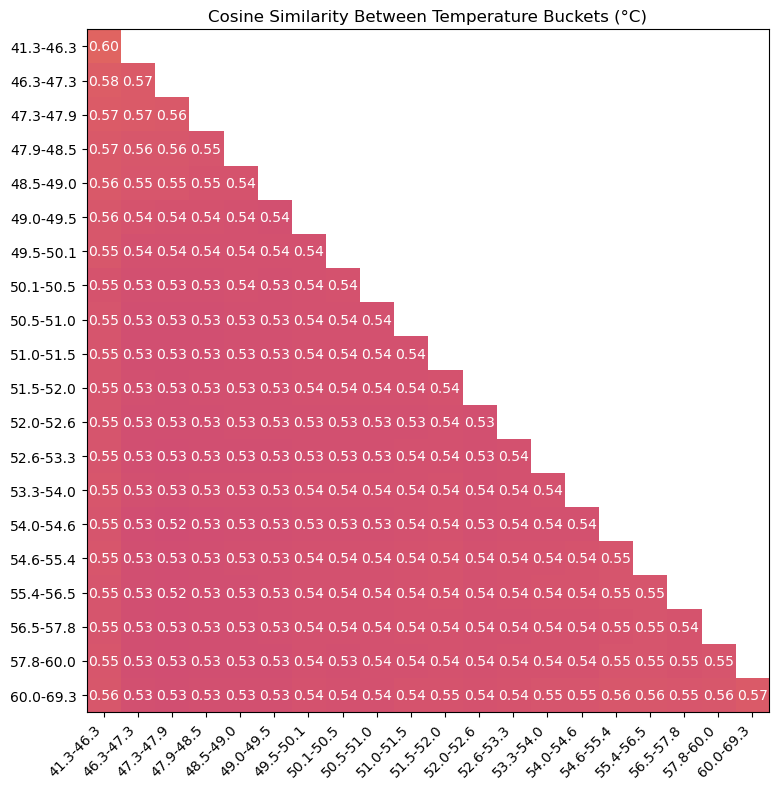

In [11]:
# Print Heat map
fig, ax = plt.subplots(figsize=(10, 8))

# Create a mask for the lower triangle
mask = np.triu(np.ones_like(sim_matrix, dtype=bool), k=1)  # k=1 excludes the diagonal
masked_sim_matrix = np.where(mask, np.nan, sim_matrix)

im = ax.imshow(np.ma.masked_invalid(masked_sim_matrix), cmap="plasma", vmin=0, vmax=1)

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(bucket_labels, rotation=45, ha="right")
ax.set_yticklabels(bucket_labels)

# Annotate visible cells
for i in range(n):
    for j in range(n):
        if i >= j and not np.isnan(sim_matrix[i, j]):
            sim = sim_matrix[i, j]
            ax.text(j, i, f"{sim:.2f}", ha="center", va="center",
                    color="white", fontsize=10)

ax.set_title("Cosine Similarity Between Temperature Buckets (°C)")
plt.tight_layout()
plt.show()